In [1]:
import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')

In [3]:
file_location = "Christian Universities as Moral Communities Drinking, Sex, and Drug use among University Students in the United States.DTA"
df = pd.read_stata(file_location)

In [4]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V115,V116,V117,V118,V119,V120,I_AGE,I_RACE,I_SEX,I_ATTEND
0,21,Asian or Pacific Islander,Female,"Senior, college",Graduate degree,Graduate degree,None,Five or more,One,None have tattoos,...,NaN,NaN,NaN,NaN,NaN,NaN,21,Asian or Pacific Islander,Female,Weekly or more often
1,20,White,Female,"Junior, college",Graduate degree,Graduate degree,None,Five or more,None have tattoos,None have tattoos,...,None,Yes,No,No,No,None,20,White,Female,Once or twice a year
2,19,White,Female,"Sophomore, college",Graduate degree,Graduate degree,One tattoo,Four,None have tattoos,One,...,NaN,NaN,NaN,NaN,NaN,NaN,19,White,Female,Once or twice a year
3,21,White,Female,"Junior, college",Some graduate school,College degree,None,Five or more,None have tattoos,None have tattoos,...,NaN,NaN,NaN,NaN,NaN,NaN,21,White,Female,Once every other month or so
4,20,White,Female,"Freshman, college",Graduate degree,Graduate degree,None,Five or more,None have tattoos,Four,...,NaN,NaN,NaN,NaN,NaN,NaN,20,White,Female,About once a month


In [6]:
df['V39'].value_counts()

V39
Strongly disagree    868
Uncertain            744
Strongly agree       699
Agree                585
Disagree             579
Name: count, dtype: int64

In [ ]:
#Views whether the bible is the infallible word of god, no errors in bible (39)


In [7]:
df['V30'].value_counts()

V30
Moderately close       1449
Moderately distant      612
Very close              576
No closeness at all     540
Very distant            315
Name: count, dtype: int64

In [ ]:
#V30: How close do you feel to God?

In [9]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       ...
       'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'I_AGE', 'I_RACE',
       'I_SEX', 'I_ATTEND'],
      dtype='str', length=124)

In [ ]:
chosen_variables = [ "V30", "V39", "V" "V79" ]
df_small = df.loc[:, chosen_variables]

In [12]:
print(df.isna().sum())

V1             9
V2            33
V3            26
V4            21
V5            60
            ... 
V120        2544
I_AGE          9
I_RACE        33
I_SEX         26
I_ATTEND     398
Length: 124, dtype: int64


In [20]:
df2 = df.dropna()

In [17]:
print(df_small.shape)


(3530, 3)


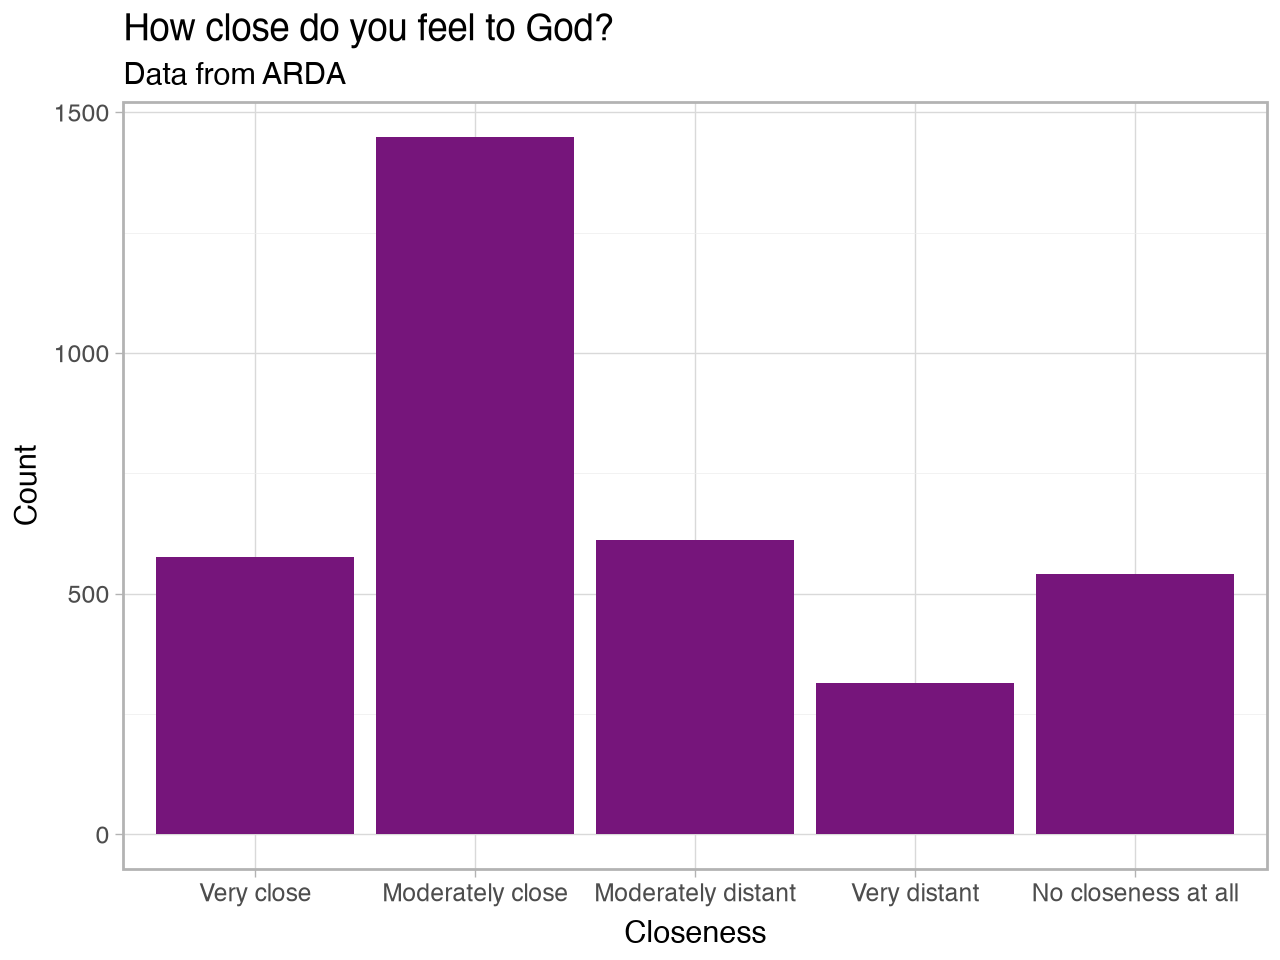

In [65]:
df_plot = df.dropna(subset=['V30'])

(
    p9.ggplot(df_plot)
    + p9.geom_bar(p9.aes(x='V30'), fill='#76157b')
    + p9.theme_light()
    + p9.labs(title='How close do you feel to God?',
              subtitle='Data from ARDA',
              x='Closeness', y='Count')
)

In [27]:
import statsmodels.formula.api as smf

In [36]:
df['V39'].value_counts()

V39
Strongly disagree    868
Uncertain            744
Strongly agree       699
Agree                585
Disagree             579
Name: count, dtype: int64

In [49]:
pd.crosstab(df['V30'], df_num['closeness_to_god'])

closeness_to_god,1.0,2.0,3.0,4.0,5.0
V30,,,,,
Very close,576,0,0,0,0
Moderately close,0,1449,0,0,0
Moderately distant,0,0,612,0,0
Very distant,0,0,0,315,0
No closeness at all,0,0,0,0,540


In [50]:
pd.crosstab(df['V39'], df_num['bible_never_wrong'])


bible_never_wrong,1.0,2.0,3.0,4.0,5.0
V39,,,,,
Strongly disagree,868,0,0,0,0
Disagree,0,579,0,0,0
Uncertain,0,0,744,0,0
Agree,0,0,0,585,0
Strongly agree,0,0,0,0,699


In [ ]:
pd.crosstab(df['V39'], df_num['bible_never_wrong'])


In [52]:
from statsmodels.iolib.summary2 import summary_col

summary_col([lm1, lm2, lm3], stars=True, model_names=['Model 1', 'Model 2', 'Model 3'])

,Model 1,Model 2,Model 3
Intercept,0.0349***,0.1345***,0.0998***
,(0.0130),(0.0126),(0.0331)
closeness_to_god,0.0169***,,0.0080
,(0.0044),,(0.0066)
bible_never_wrong,,-0.0187***,-0.0144**
,,(0.0039),(0.0057)
R-squared,0.0043,0.0068,0.0073
R-squared Adj.,0.0040,0.0065,0.0067


In [54]:
df_num['drug_abuse'].value_counts()

drug_abuse
0.0    3221
1.0     195
2.0      21
3.0      14
Name: count, dtype: int64

In [55]:
df_num['any_drug_abuse'] = (df_num['drug_abuse'] > 0).astype(float).where(df_num['drug_abuse'].notna())
df_num['any_drug_abuse'].value_counts()

/var/folders/34/rtv3b4xn46g051vpjd0y_czr0000gn/T/ipykernel_56590/2679929926.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


any_drug_abuse
0.0    3221
1.0     230
Name: count, dtype: int64

In [56]:
lg1 = smf.logit('any_drug_abuse ~ bible_never_wrong + closeness_to_god', data=df_num).fit()
print(lg1.summary())

Optimization terminated successfully.
         Current function value: 0.234531
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         any_drug_abuse   No. Observations:                 3387
Model:                          Logit   Df Residuals:                     3384
Method:                           MLE   Df Model:                            2
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                 0.02436
Time:                        19:17:12   Log-Likelihood:                -794.36
converged:                       True   LL-Null:                       -814.19
Covariance Type:            nonrobust   LLR p-value:                 2.431e-09
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.5135      0.308     -8.150      0.000      -3.118      -1.909
bible_ne

In [ ]:
# Controlling for each other, people who agree more strongly that the Bible is true are less likely to report any drug abuse
# and people with a higher closeness score are more likely to. To report these as effect sizes, use the odds ratios from 
# your other table: 0.81 for Bible belief (about 19% lower odds per step) and 1.15 for closeness (about 15% higher odds per step).

In [64]:
print(pd.crosstab(df['V39'], df_num['bible_never_wrong']))
print(pd.crosstab(df['V30'], df_num['closeness_to_god']))

bible_never_wrong  1.0  2.0  3.0  4.0  5.0
V39                                       
Strongly disagree  868    0    0    0    0
Disagree             0  579    0    0    0
Uncertain            0    0  744    0    0
Agree                0    0    0  585    0
Strongly agree       0    0    0    0  699
closeness_to_god     1.0   2.0  3.0  4.0  5.0
V30                                          
Very close           576     0    0    0    0
Moderately close       0  1449    0    0    0
Moderately distant     0     0  612    0    0
Very distant           0     0    0  315    0
No closeness at all    0     0    0    0  540


In [57]:
import numpy as np

odds = np.exp(lg1.params)
ci = np.exp(lg1.conf_int())
ci.columns = ['2.5%', '97.5%']
pd.concat([odds.rename('odds_ratio'), ci], axis=1)

,odds_ratio,2.5%,97.5%
Intercept,0.080980,0.044245,0.148215
bible_never_wrong,0.809011,0.716927,0.912922
closeness_to_god,1.153157,1.020805,1.302670


In [58]:
print(lg1.get_margeff().summary())

        Logit Marginal Effects       
Dep. Variable:         any_drug_abuse
Method:                          dydx
At:                           overall
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
bible_never_wrong    -0.0127      0.004     -3.389      0.001      -0.020      -0.005
closeness_to_god      0.0085      0.004      2.279      0.023       0.001       0.016


In [63]:
pd.crosstab(df['V39'], df_num['bible_never_wrong'])
pd.crosstab(df['V30'], df_num['closeness_to_god'])
df_num[['bible_never_wrong', 'closeness_to_god']].corr()

,bible_never_wrong,closeness_to_god
bible_never_wrong,1.000000,-0.570775
closeness_to_god,-0.570775,1.000000


In [60]:
print(pd.crosstab(df['V39'], df_num['bible_never_wrong']))
print(pd.crosstab(df['V30'], df_num['closeness_to_god']))
print(df_num[['bible_never_wrong', 'closeness_to_god']].corr())

bible_never_wrong  1.0  2.0  3.0  4.0  5.0
V39                                       
Strongly disagree  868    0    0    0    0
Disagree             0  579    0    0    0
Uncertain            0    0  744    0    0
Agree                0    0    0  585    0
Strongly agree       0    0    0    0  699
closeness_to_god     1.0   2.0  3.0  4.0  5.0
V30                                          
Very close           576     0    0    0    0
Moderately close       0  1449    0    0    0
Moderately distant     0     0  612    0    0
Very distant           0     0    0  315    0
No closeness at all    0     0    0    0  540
                   bible_never_wrong  closeness_to_god
bible_never_wrong           1.000000         -0.570775
closeness_to_god           -0.570775          1.000000


In [78]:
analysis = analysis.rename(columns={
    "V30": "closeness_to_god",
    "V39": "bible_never_wrong",
    "V40": "true_christians_fully_believe_bible",
    "V41": "the_bible_is_complete_guide_to_morality",
    "V79": "drug_abuse"
})


In [81]:
analysis["drug_abuse"] = (analysis["drug_abuse"] > 0).astype(int)

model = smf.logit(
    "drug_abuse ~ closeness_to_god + bible_never_wrong + true_christians_fully_believe_bible + the_bible_is_complete_guide_to_morality",
    data=analysis
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.231008
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             drug_abuse   No. Observations:                 3350
Model:                          Logit   Df Residuals:                     3345
Method:                           MLE   Df Model:                            4
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                 0.02739
Time:                        13:50:30   Log-Likelihood:                -773.88
converged:                       True   LL-Null:                       -795.67
Covariance Type:            nonrobust   LLR p-value:                 7.796e-09
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -2.2635

In [ ]:
# When studied individually, the P values are not statistically significant for each independent variable as P > 0.05.
# Variable	p-value
# Intercept	0.000
# closeness_to_god	0.064
#bible_never_wrong	0.741
#true_christians_fully_believe_bible	0.331
#the_bible_is_complete_guide_to_morality	0.071

In [82]:
bible_items = ["bible_never_wrong", "true_christians_fully_believe_bible", "the_bible_is_complete_guide_to_morality"]
print(analysis[bible_items].corr())

                                         bible_never_wrong  \
bible_never_wrong                                 1.000000   
true_christians_fully_believe_bible               0.790100   
the_bible_is_complete_guide_to_morality           0.789199   

                                         true_christians_fully_believe_bible  \
bible_never_wrong                                                   0.790100   
true_christians_fully_believe_bible                                 1.000000   
the_bible_is_complete_guide_to_morality                             0.733516   

                                         the_bible_is_complete_guide_to_morality  
bible_never_wrong                                                       0.789199  
true_christians_fully_believe_bible                                     0.733516  
the_bible_is_complete_guide_to_morality                                 1.000000  


In [ ]:
#High correlation (1.0, 0.79 and 0.789. )

In [83]:
print(model.wald_test(
    "bible_never_wrong = 0, true_christians_fully_believe_bible = 0, the_bible_is_complete_guide_to_morality = 0",
    scalar=True
))

<Wald test (chi2): statistic=16.51026057642379, p-value=0.0008910613185197177, df_denom=3>


In [ ]:
#Combined model with all four variables merged. Wald test done.
analysis["bible_scale"] = analysis[bible_items].mean(axis=1)

model2 = smf.logit("drug_abuse ~ closeness_to_god + bible_scale", data=analysis).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.231117
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             drug_abuse   No. Observations:                 3350
Model:                          Logit   Df Residuals:                     3347
Method:                           MLE   Df Model:                            2
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                 0.02693
Time:                        13:54:59   Log-Likelihood:                -774.24
converged:                       True   LL-Null:                       -795.67
Covariance Type:            nonrobust   LLR p-value:                 4.931e-10
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.2791      0.331     -6.894      0.000      -2.927      -1.631
closeness_t

In [86]:
analysis["drug_abuse"].value_counts()

drug_abuse
0    3136
1     214
Name: count, dtype: int64

In [87]:
from statsmodels.iolib.summary2 import summary_col

In [113]:
table = summary_col(
    [model, model2],
    model_names=["Separate Items", "Religious Beliefs Scale"],
    stars=True,
    float_format="%.3f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "Pseudo R²": lambda x: f"{x.prsquared:.3f}",
        "Log-Likelihood": lambda x: f"{x.llf:.1f}",
        "AIC": lambda x: f"{x.aic:.1f}",
    },
)

sg.rename_covariates({
    'closeness_to_god':       'Closeness to God',
    'bible_never_wrong':     'Belief that the Bible is Never Wrong',
    'true_christians_fully_believe_bible':       'Believe that true Christians fully believe the Bible',
    'the_bible_is_complete_guide_to_morality':      'Believe Bible is the complete guide to morality',
    'bible_scale':     'Bible Scale',
})
print(table)


                                        Separate Items Religious Beliefs Scale
------------------------------------------------------------------------------
Intercept                               -2.263***      -2.279***              
                                        (0.334)        (0.331)                
closeness_to_god                        0.120*         0.122*                 
                                        (0.065)        (0.063)                
bible_never_wrong                       -0.032                                
                                        (0.098)                               
true_christians_fully_believe_bible     -0.082                                
                                        (0.085)                               
the_bible_is_complete_guide_to_morality -0.165*                               
                                        (0.091)                               
bible_scale                                        

In [ ]:
#Replacing the three items with a religious beliefs scale produced a simpler model with an equivalent fit with a lower AIC.

In [93]:
%pip install stargazer

Python(78354) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [95]:
from stargazer.stargazer import Stargazer

sg = Stargazer([model, model2])

In [98]:


sg.dependent_variable_name('Drug Abuse')
sg.custom_columns(['Individual', 'Combined'], [1, 1])

# 1. Order using ORIGINAL names
sg.covariate_order([
    'closeness_to_god', 'bible_never_wrong', 'true_christians_fully_believe_bible', 'the_bible_is_complete_guide_to_morality',
    'bible_scale'
])

# 2. Rename to readable labels
sg.rename_covariates({
    'closeness_to_god':       'Closeness to God',
    'bible_never_wrong':     'Belief that the Bible is Never Wrong',
    'true_christians_fully_believe_bible':       'Believe that true Christians fully believe the Bible',
    'the_bible_is_complete_guide_to_morality':      'Believe Bible is the complete guide to morality',
    'bible_scale':     'Bible Scale',
    'Intercept':       'Intercept',
})

sg

In [ ]:
# Stronger Bible Belief = less likely to use illegal drugs. 24% less likely to use drugs for every point increase on the scale 
# for stronger bible belief (bible scale). Very statistically significant!
#Closeness to God is marginally significant when it comes to drug usage. Belief that Bible is never wrong and that
# true Christians fully believe the Bible is not statistically significant. Only the Belief that the Bible is the complete guide
#to morality is marginally statistically significant. 
#Feeling less close to God = higher chance of abusing illegal drugs (b = 0.12, p < .1).

In [99]:
god_map = {1: 5, 2: 4, 3: 3, 4: 2, 5: 1, 6: np.nan}
df_num["god_belief"] = df_raw["V31"].map(god_map)

/var/folders/34/rtv3b4xn46g051vpjd0y_czr0000gn/T/ipykernel_56590/2961184718.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [100]:
df_num = df_num.copy()

In [102]:
df_num["salvation"] = df_raw["V33"].map({
    1: "One true faith",
    2: "Many religions",
    3: "No salvation",
    4: np.nan          # "I don't know" -> missing
})

In [108]:
df_num["bible_scale"] = analysis["bible_scale"]

In [114]:
df_num["any_drug_abuse"] = (df_num["drug_abuse"] > 0).astype(float).where(df_num["drug_abuse"].notna())

lg_sal = smf.logit(
    "any_drug_abuse ~ C(salvation, Treatment('Many religions')) + bible_scale",
    data=df_num
).fit()
print(lg_sal.summary())

Optimization terminated successfully.
         Current function value: 0.215699
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         any_drug_abuse   No. Observations:                 2569
Model:                          Logit   Df Residuals:                     2565
Method:                           MLE   Df Model:                            3
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                 0.03529
Time:                        00:50:32   Log-Likelihood:                -554.13
converged:                       True   LL-Null:                       -574.41
Covariance Type:            nonrobust   LLR p-value:                 8.158e-09
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
# Belief in Salvation not significant- but Bible Scale still convincing and statistically significant. 